In [2]:
import pandas as pd
import numpy as np
import re
import nltk
import spacy
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, Conv1D, GlobalMaxPooling1D, LSTM, Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences


In [5]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [10]:
df = pd.read_csv('/content/SMSSpamCollection.unknown',
                 sep="\t", names=["label", "message"])

In [11]:
print("Dataset shape:", df.shape)
print("First 5 rows:\n", df.head())


Dataset shape: (5572, 2)
First 5 rows:
   label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


In [12]:
X = df["message"]
y = df["label"]
print("X shape:", X.shape, "y shape:", y.shape)


X shape: (5572,) y shape: (5572,)


In [13]:
ps = PorterStemmer()
stop_words = set(stopwords.words("english"))
nlp = spacy.load("en_core_web_sm")


In [14]:
def clean_text(text):
      text = re.sub(r'\d+|\W+', ' ', text)
      text = text.lower()
      return text

df["cleaned"] = df["message"].apply(clean_text)


In [15]:
df["tokens"] = df["cleaned"].apply(word_tokenize)
df["stems"] = df["tokens"].apply(lambda tokens: [ps.stem(w) for w in tokens if w not in stop_words])

In [ ]:
df["tokens"] = df["cleaned"].apply(lambda text: [token.text for token in nlp(text)])
df["stems"] = df["tokens"].apply(lambda tokens: [ps.stem(w) for w in tokens if w not in stop_words])

In [ ]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
_stems = [w for stems in df["stems"] for w in stems]
freq_dist = nltk.FreqDist(_stems)
print("Top 10 frequent stems:", freq_dist.most_common(10))

Top 10 frequent stems: [('  ', 2366), ('u', 1228), (' ', 1102), ('call', 695), ('go', 462), ('get', 458), ('ur', 391), ('nt', 349), ('gt', 318), ('lt', 316)]


In [ ]:
def spacy_process(text):
    doc = nlp(text)
    lemmas = [token.lemma_ for token in doc if token.is_alpha and token.pos_ in ["NOUN","VERB"]]
    return lemmas

In [ ]:
df["lemmas"] = df["cleaned"].apply(spacy_process)
all_lemmas = [w for lem in df["lemmas"] for w in lem]
lemma_freq = nltk.FreqDist(all_lemmas)
print("Top 10 frequent lemmas:", lemma_freq.most_common(10))


Top 10 frequent lemmas: [('call', 689), ('get', 662), ('go', 616), ('have', 537), ('s', 414), ('do', 349), ('come', 325), ('m', 307), ('day', 290), ('know', 286)]


In [ ]:
pos_counts = {}
for text in df["cleaned"].sample(100):
    doc = nlp(text)
    for token in doc:
        pos_counts[token.pos_] = pos_counts.get(token.pos_, 0) + 1

print("POS Frequency:", pos_counts)

POS Frequency: {'PART': 36, 'ADV': 107, 'PROPN': 125, 'VERB': 266, 'INTJ': 36, 'PRON': 236, 'AUX': 85, 'ADJ': 100, 'NOUN': 299, 'ADP': 103, 'SPACE': 68, 'DET': 79, 'SCONJ': 33, 'CCONJ': 29, 'X': 4, 'SYM': 1, 'NUM': 1}


In [ ]:
verbs = [t.lemma_ for doc in df["cleaned"].apply(nlp) for t in doc if t.pos_=="VERB"]
adjs  = [t.lemma_ for doc in df["cleaned"].apply(nlp) for t in doc if t.pos_=="ADJ"]


In [ ]:
verb_freq = nltk.FreqDist(verbs).most_common(10)
adj_freq  = nltk.FreqDist(adjs).most_common(10)

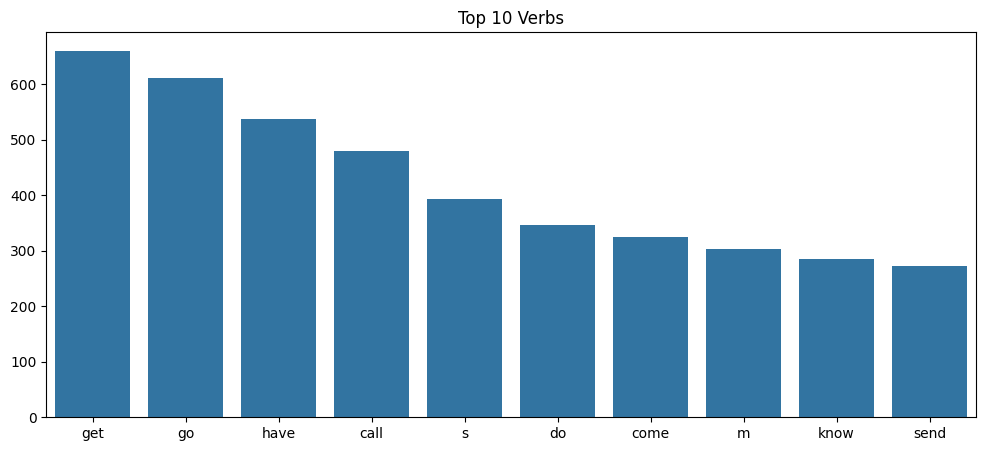

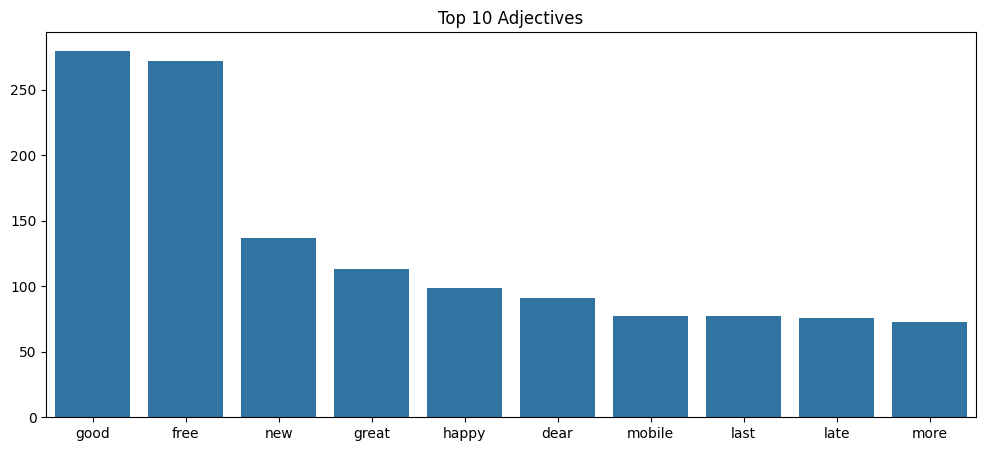

In [ ]:
plt.figure(figsize=(12,5))
sns.barplot(x=[v[0] for v in verb_freq], y=[v[1] for v in verb_freq])
plt.title("Top 10 Verbs")
plt.show()

plt.figure(figsize=(12,5))
sns.barplot(x=[a[0] for a in adj_freq], y=[a[1] for a in adj_freq])
plt.title("Top 10 Adjectives")
plt.show()

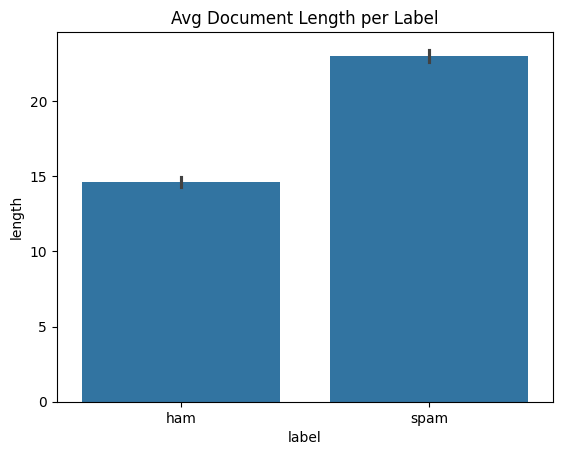

In [ ]:
df["length"] = df["cleaned"].apply(lambda x: len(x.split()))
sns.barplot(x="label", y="length", data=df)
plt.title("Avg Document Length per Label")
plt.show()

In [ ]:
cv = CountVectorizer(ngram_range=(1,2))
X_cv = cv.fit_transform(df["cleaned"])
print("Vocabulary size:", len(cv.vocabulary_))


Vocabulary size: 48084


In [ ]:
sum_words = X_cv.sum(axis=0)
words_freq = [(w, sum_words[0, i]) for w, i in cv.vocabulary_.items()]
words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
print("Most common bigrams/unigrams:", words_freq[:10])

Most common bigrams/unigrams: [('to', np.int64(2253)), ('you', np.int64(2247)), ('the', np.int64(1343)), ('and', np.int64(980)), ('in', np.int64(907)), ('is', np.int64(897)), ('me', np.int64(808)), ('my', np.int64(767)), ('it', np.int64(752)), ('for', np.int64(711))]


In [ ]:
tfidf = TfidfVectorizer(stop_words="english")
X_tfidf = tfidf.fit_transform(df["cleaned"])

X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)


In [ ]:
models = {
      "Logistic Regression": LogisticRegression(max_iter=500),
       "SVM": SVC(),
       "Random Forest": RandomForestClassifier()
}


In [ ]:
for name, model in models.items():
      model.fit(X_train, y_train)
      preds = model.predict(X_test)
      print(f"\n{name} Performance:")
      print("Accuracy:", accuracy_score(y_test, preds))
      print("Precision:", precision_score(y_test, preds, pos_label="spam"))
      print("Recall:", recall_score(y_test, preds, pos_label="spam"))
      print("F1:", f1_score(y_test, preds, pos_label="spam"))



Logistic Regression Performance:
Accuracy: 0.9650224215246637
Precision: 1.0
Recall: 0.738255033557047
F1: 0.8494208494208494

SVM Performance:
Accuracy: 0.9757847533632287
Precision: 1.0
Recall: 0.8187919463087249
F1: 0.9003690036900369

Random Forest Performance:
Accuracy: 0.9748878923766816
Precision: 1.0
Recall: 0.8120805369127517
F1: 0.8962962962962963


In [ ]:
max_words = 5000
max_len = 100

In [ ]:
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(df["cleaned"])
X_seq = tokenizer.texts_to_sequences(df["cleaned"])
X_pad = pad_sequences(X_seq, maxlen=max_len)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_pad, (y=="spam").astype(int),
                                                    test_size=0.2, random_state=42)

In [ ]:
mlp = Sequential([
      Embedding(max_words, 32, input_length=max_len),
      GlobalMaxPooling1D(),
      Dense(10, activation="relu"),
      Dense(1, activation="sigmoid")
])
mlp.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
mlp.fit(X_train, y_train, epochs=3, batch_size=32, validation_split=0.2)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/3
112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.7527 - loss: 0.5538 - val_accuracy: 0.8576 - val_loss: 0.3926
Epoch 2/3
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8588 - loss: 0.3732 - val_accuracy: 0.8576 - val_loss: 0.3159
Epoch 3/3
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8844 - loss: 0.2463 - val_accuracy: 0.9608 - val_loss: 0.1492


In [ ]:
cnn = Sequential([
      Embedding(max_words, 32, input_length=max_len),
      Conv1D(64, 5, activation="relu"),
      GlobalMaxPooling1D(),
      Dense(1, activation="sigmoid")
])
cnn.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
cnn.fit(X_train, y_train, epochs=3, batch_size=32, validation_split=0.2)

Epoch 1/3
112/112 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.8152 - loss: 0.4847 - val_accuracy: 0.8913 - val_loss: 0.2248
Epoch 2/3
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9608 - loss: 0.1308 - val_accuracy: 0.9809 - val_loss: 0.0760
Epoch 3/3
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9909 - loss: 0.0377 - val_accuracy: 0.9809 - val_loss: 0.0661


In [ ]:
bilstm = Sequential([
      Embedding(max_words, 32, input_length=max_len),
      Bidirectional(LSTM(32)),
      Dense(1, activation="sigmoid")
])
bilstm.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
bilstm.fit(X_train, y_train, epochs=3, batch_size=32, validation_split=0.2)

Epoch 1/3
112/112 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.8385 - loss: 0.4134 - val_accuracy: 0.9585 - val_loss: 0.1513
Epoch 2/3
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9836 - loss: 0.0760 - val_accuracy: 0.9809 - val_loss: 0.0683
Epoch 3/3
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9916 - loss: 0.0385 - val_accuracy: 0.9821 - val_loss: 0.0604


In [ ]:
# Create the 'cleaned' column
df['cleaned'] = df['message'].apply(clean_text)
print("Cleaned column created successfully.")
print(df.head())


Cleaned column created successfully.
  label                                            message  \
0   ham  Go until jurong point, crazy.. Available only ...   
1   ham                      Ok lar... Joking wif u oni...   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...   
3   ham  U dun say so early hor... U c already then say...   
4   ham  Nah I don't think he goes to usf, he lives aro...   

                                             cleaned  \
0  go until jurong point crazy available only in ...   
1                           ok lar joking wif u oni    
2  free entry in   a wkly comp to win fa cup fina...   
3       u dun say so early hor u c already then say    
4  nah i don t think he goes to usf he lives arou...   

                                              tokens  \
0  [go, until, jurong, point, crazy, available, o...   
1                     [ok, lar, joking, wif, u, oni]   
2  [free, entry, in,   , a, wkly, comp, to, win, ...   
3  [u, dun, say, so, early, h

word2vec+lstm & glove+lstm

In [ ]:
# ============================================
# 🌐 WORD2VEC + LSTM
# ============================================
from gensim.models import Word2Vec
print("\nTraining Word2Vec-LSTM Model...")
# Ensure the 'cleaned' column exists
def clean_text(text):
      text = re.sub(r'\d+|\W+', ' ', text)
      text = text.lower()
      return text

df["cleaned"] = df["message"].apply(clean_text)

tokenized = [text.split() for text in df["cleaned"]]
w2v_model = Word2Vec(sentences=tokenized, vector_size=100, window=5, min_count=1, workers=4)
vocab_size = len(tokenizer.word_index) + 1
embedding_matrix = np.zeros((vocab_size, 100))
for word, i in tokenizer.word_index.items():
    if word in w2v_model.wv:
        embedding_matrix[i] = w2v_model.wv[word]

w2v_lstm = Sequential([
    Embedding(vocab_size, 100, weights=[embedding_matrix], input_length=max_len, trainable=False),
    LSTM(64, dropout=0.2, recurrent_dropout=0.2),
    Dense(1, activation='sigmoid')
])
w2v_lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
w2v_lstm.fit(X_train, y_train, epochs=3, batch_size=32, validation_split=0.2)
loss, acc = w2v_lstm.evaluate(X_test, y_test, verbose=0)
print(f"\nWord2Vec-LSTM Test Accuracy: {acc:.4f}")

# ============================================
# 🌍 GloVe + LSTM
# ============================================
print("\nTraining GloVe-LSTM Model...")
glove_path = '/content/glove.6B.100d.txt'
embeddings_index = {}
with open(glove_path, encoding='utf8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coefs

embedding_matrix_glove = np.zeros((vocab_size, 100))
for word, i in tokenizer.word_index.items():
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        embedding_matrix_glove[i] = embedding_vector

glove_lstm = Sequential([
    Embedding(vocab_size, 100, weights=[embedding_matrix_glove], input_length=max_len, trainable=False),
    LSTM(64, dropout=0.2, recurrent_dropout=0.2),
    Dense(1, activation='sigmoid')
])
glove_lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
glove_lstm.fit(X_train, y_train, epochs=3, batch_size=32, validation_split=0.2)
loss, acc = glove_lstm.evaluate(X_test, y_test, verbose=0)
print(f"\nGloVe-LSTM Test Accuracy: {acc:.4f}")


Training Word2Vec-LSTM Model...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/3
112/112 ━━━━━━━━━━━━━━━━━━━━ 83s 652ms/step - accuracy: 0.8197 - loss: 0.4288 - val_accuracy: 0.8879 - val_loss: 0.2930
Epoch 2/3
112/112 ━━━━━━━━━━━━━━━━━━━━ 78s 641ms/step - accuracy: 0.8792 - loss: 0.2796 - val_accuracy: 0.9047 - val_loss: 0.2552
Epoch 3/3
112/112 ━━━━━━━━━━━━━━━━━━━━ 59s 433ms/step - accuracy: 0.9016 - loss: 0.2407 - val_accuracy: 0.9260 - val_loss: 0.2061

Word2Vec-LSTM Test Accuracy: 0.9390

Training GloVe-LSTM Model...
Epoch 1/3
112/112 ━━━━━━━━━━━━━━━━━━━━ 41s 343ms/step - accuracy: 0.8862 - loss: 0.3183 - val_accuracy: 0.9619 - val_loss: 0.1219
Epoch 2/3
112/112 ━━━━━━━━━━━━━━━━━━━━ 39s 347ms/step - accuracy: 0.9594 - loss: 0.1202 - val_accuracy: 0.9596 - val_loss: 0.1093
Epoch 3/3
112/112 ━━━━━━━━━━━━━━━━━━━━ 37s 311ms/step - accuracy: 0.9688 - loss: 0.0981 - val_accuracy: 0.9664 - val_loss: 0.0880

GloVe-LSTM Test Accuracy: 0.9794


In [ ]:
!ls /content/

sample_data  SMSSpamCollection.unknown	SMSSpamCollection.zip


In [ ]:
from gensim.models import Word2Vec

In [ ]:
!wget http://nlp.stanford.edu/data/glove.6B.zip
!unzip -q glove.6B.zip -d /content/

--2025-11-17 04:40:53--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2025-11-17 04:40:53--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2025-11-17 04:40:53--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glov

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('/content/SMSSpamCollection.unknown',
                 sep="\t", names=["label", "message"])

In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 19.7 MB/s eta 0:00:00


confusion matrix

35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step


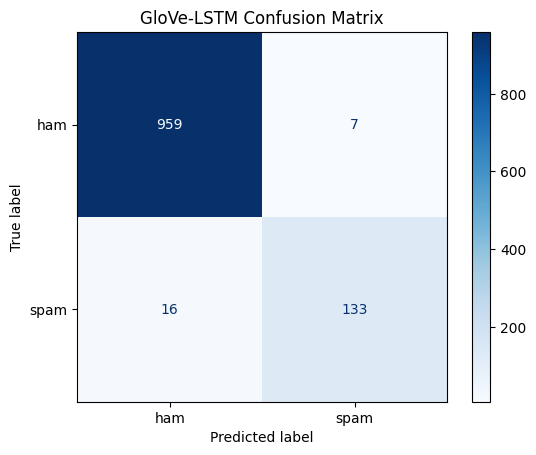


Classification Report (GloVe-LSTM):

              precision    recall  f1-score   support

         ham       0.98      0.99      0.99       966
        spam       0.95      0.89      0.92       149

    accuracy                           0.98      1115
   macro avg       0.97      0.94      0.95      1115
weighted avg       0.98      0.98      0.98      1115



In [ ]:
# ============================================
# 📊 Confusion Matrix for Deep Model
# ============================================
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

y_pred = (glove_lstm.predict(X_test) > 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["ham", "spam"])
disp.plot(cmap="Blues")
plt.title("GloVe-LSTM Confusion Matrix")
plt.show()

print("\nClassification Report (GloVe-LSTM):\n")
print(classification_report(y_test, y_pred, target_names=["ham", "spam"]))

In [ ]:
# Re-run the cell to define glove_lstm

# Ensure GloVe embeddings are present
!wget -nc http://nlp.stanford.edu/data/glove.6B.zip # -nc means 'no clobber', won't re-download if exists
!unzip -q -n glove.6B.zip -d /content/ # -n means 'never overwrite existing files'

print("\nTraining GloVe-LSTM Model...")
glove_path = '/content/glove.6B.100d.txt'
embeddings_index = {}
with open(glove_path, encoding='utf8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coefs

embedding_matrix_glove = np.zeros((vocab_size, 100))
for word, i in tokenizer.word_index.items():
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        embedding_matrix_glove[i] = embedding_vector

glove_lstm = Sequential([
    Embedding(vocab_size, 100, weights=[embedding_matrix_glove], input_length=max_len, trainable=False),
    LSTM(64, dropout=0.2, recurrent_dropout=0.2),
    Dense(1, activation='sigmoid')
])
glove_lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
glove_lstm.fit(X_train, y_train, epochs=3, batch_size=32, validation_split=0.2)
loss, acc = glove_lstm.evaluate(X_test, y_test, verbose=0)
print(f"\nGloVe-LSTM Test Accuracy: {acc:.4f}")

File ‘glove.6B.zip’ already there; not retrieving.


Training GloVe-LSTM Model...
Epoch 1/3


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


112/112 ━━━━━━━━━━━━━━━━━━━━ 39s 322ms/step - accuracy: 0.8509 - loss: 0.3608 - val_accuracy: 0.9608 - val_loss: 0.1188
Epoch 2/3
112/112 ━━━━━━━━━━━━━━━━━━━━ 36s 320ms/step - accuracy: 0.9615 - loss: 0.1124 - val_accuracy: 0.9720 - val_loss: 0.0867
Epoch 3/3
112/112 ━━━━━━━━━━━━━━━━━━━━ 35s 309ms/step - accuracy: 0.9715 - loss: 0.0850 - val_accuracy: 0.9753 - val_loss: 0.0818

GloVe-LSTM Test Accuracy: 0.9830


precision

In [ ]:
from sklearn.metrics import precision_score

models = ['Word2Vec-LSTM', 'GloVe-LSTM']

# Get predictions from the trained models
y_pred_word2vec = (w2v_lstm.predict(X_test) > 0.5).astype(int)
y_pred_glove = (glove_lstm.predict(X_test) > 0.5).astype(int)

y_preds = [y_pred_word2vec, y_pred_glove]

for model, pred in zip(models, y_preds):
    prec = precision_score(y_test, pred, average='binary', pos_label=1)
    print(f"{model} Precision: {prec:.4f}")

35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step
Word2Vec-LSTM Precision: 0.7547
GloVe-LSTM Precision: 0.9577


recall

In [ ]:
from sklearn.metrics import recall_score

models = ['Word2Vec-LSTM', 'GloVe-LSTM']
y_preds = [y_pred_word2vec, y_pred_glove]

for model, pred in zip(models, y_preds):
    rec = recall_score(y_test, pred, average='binary', pos_label=1)
    print(f"{model} Recall: {rec:.4f}")

Word2Vec-LSTM Recall: 0.8054
GloVe-LSTM Recall: 0.9128


fn score

In [ ]:
from sklearn.metrics import f1_score

models = ['Word2Vec-LSTM', 'GloVe-LSTM']
y_preds = [y_pred_word2vec, y_pred_glove]

for model, pred in zip(models, y_preds):
    f1 = f1_score(y_test, pred, average='binary', pos_label=1)
    print(f"{model} F1-Score: {f1:.4f}")

Word2Vec-LSTM F1-Score: 0.7792
GloVe-LSTM F1-Score: 0.9347


In [ ]:
# ============================================
# 🚀 CPU-FRIENDLY DISTILBERT TRAINING
# ============================================

!pip install transformers torch --quiet

import torch
from torch.utils.data import Dataset, DataLoader
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification
from torch.optim import AdamW # Corrected import path for AdamW
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

import pandas as pd # Import pandas
import re # Import re for clean_text

# Ensure the dataset file is present by unzipping it
!unzip -o /content/smsspamcollection.zip -d /content/

# Define clean_text function early
def clean_text(text):
      text = re.sub(r'\d+|\W+', ' ', text)
      text = text.lower()
      return text

# Load data and preprocess 'cleaned' column (ensure df and cleaned column exist)
df = pd.read_csv('/content/SMSSpamCollection.unknown', sep="\t", names=["label", "message"])
df["cleaned"] = df["message"].apply(clean_text)

# Device check
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Use DistilBERT (faster than BERT)
tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

# Convert cleaned text (already prepared in your code)
texts = df["cleaned"].tolist()
labels = (df["label"] == "spam").astype(int).tolist()

# Train-test split
from sklearn.model_selection import train_test_split
train_texts, test_texts, train_labels, test_labels = train_test_split(
    texts, labels, test_size=0.2, random_state=42
)

class SpamDataset(Dataset):
    def __init__(self, texts, labels):
        self.enc = tokenizer(
            texts,
            truncation=True,
            padding="max_length",
            max_length=64,     # shorter = faster on CPU
            return_tensors="pt"
        )
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids": self.enc["input_ids"][idx],
            "attention_mask": self.enc["attention_mask"][idx],
            "labels": self.labels[idx],
        }

train_dataset = SpamDataset(train_texts, train_labels)
test_dataset = SpamDataset(test_texts, test_labels)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)  # batch=8 works on CPU
test_loader = DataLoader(test_dataset, batch_size=8)

# Load DistilBERT (much faster than BERT)
model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased", num_labels=2
)
model.to(device)

optimizer = AdamW(model.parameters(), lr=3e-5)

# TRAINING LOOP (fast)
epochs = 3   # Adjusted epochs for better demonstration, original was 1
model.train()

for epoch in range(epochs):
    total_loss = 0
    for batch in train_loader:

        optimizer.zero_grad()

        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = model(**batch)
        loss = outputs.loss
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1} completed. Loss = {total_loss/len(train_loader):.4f}")

# ============================
# 🔍 Evaluation
# ============================

model.eval()
preds, actual = [], []

with torch.no_grad():
    for batch in test_loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        logits = model(**batch).logits
        preds.extend(torch.argmax(logits, axis=1).cpu().numpy())
        actual.extend(batch["labels"].cpu().numpy())

print("\n📌 DistilBERT CPU Performance:")
print("Accuracy:", accuracy_score(actual, preds))
print("Precision:", precision_score(actual, preds))
print("Recall:", recall_score(actual, preds))
print("F1 Score:", f1_score(actual, preds))

print("\nClassification Report:\n")
print(classification_report(actual, preds, target_names=["ham", "spam"]))


unzip:  cannot find or open /content/smsspamcollection.zip, /content/smsspamcollection.zip.zip or /content/smsspamcollection.zip.ZIP.
Using device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1 completed. Loss = 0.0916
Epoch 2 completed. Loss = 0.0263
Epoch 3 completed. Loss = 0.0102

📌 DistilBERT CPU Performance:
Accuracy: 0.9910313901345291
Precision: 1.0
Recall: 0.9328859060402684
F1 Score: 0.9652777777777778

Classification Report:

              precision    recall  f1-score   support

         ham       0.99      1.00      0.99       966
        spam       1.00      0.93      0.97       149

    accuracy                           0.99      1115
   macro avg       0.99      0.97      0.98      1115
weighted avg       0.99      0.99      0.99      1115



In [ ]:
# ============================================
# 🤖 BERT-to-BERT for Spam Classification
# ============================================
!pip install transformers torch --quiet

import torch
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertForSequenceClassification
from torch.optim import AdamW # Corrected import path for AdamW
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

import pandas as pd # Import pandas
import re # Import re for clean_text
from sklearn.model_selection import train_test_split # Import train_test_split

# Ensure the dataset file is present (if not already handled)
# This assumes 'SMSSpamCollection.unknown' is the correct file path as used previously
df = pd.read_csv('/content/SMSSpamCollection.unknown', sep="\t", names=["label", "message"])

def clean_text(text):
      text = re.sub(r'\d+|\W+', ' ', text)
      text = text.lower()
      return text

df["cleaned"] = df["message"].apply(clean_text)

# Device check
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Load pre-trained BERT tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Prepare texts and labels
texts = df["cleaned"].tolist()
labels = (df["label"] == "spam").astype(int).tolist() # Convert labels to 0s and 1s

# Train-test split for BERT
train_texts, test_texts, train_labels, test_labels = train_test_split(
    texts, labels, test_size=0.2, random_state=42
)

class SpamDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = int(self.labels[idx])
        encoding = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

train_dataset = SpamDataset(train_texts, train_labels, tokenizer)
test_dataset = SpamDataset(test_texts, test_labels, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# Load pre-trained BERT model for classification
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)
model = model.to(device)

optimizer = AdamW(model.parameters(), lr=2e-5)

# Training loop
epochs = 2
model.train()
for epoch in range(epochs):
    total_loss = 0
    for batch in train_loader:
        optimizer.zero_grad()
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        total_loss += loss.item()
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(train_loader):.4f}")

# Evaluation
model.eval()
preds, true_labels = [], []
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device) # Keep track of original labels for comparison
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
        true_labels.extend(labels.cpu().numpy())

# Metrics
print("\nBERT Performance:")
print("Accuracy:", accuracy_score(true_labels, preds))
print("Precision:", precision_score(true_labels, preds))
print("Recall:", recall_score(true_labels, preds))
print("F1-Score:", f1_score(true_labels, preds))
print("\nClassification Report:\n", classification_report(true_labels, preds, target_names=["ham", "spam"]))


Using device: cuda


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/2, Loss: 0.1170
Epoch 2/2, Loss: 0.0331

BERT Performance:
Accuracy: 0.9820627802690582
Precision: 0.9006211180124224
Recall: 0.9731543624161074
F1-Score: 0.9354838709677419

Classification Report:
               precision    recall  f1-score   support

         ham       1.00      0.98      0.99       966
        spam       0.90      0.97      0.94       149

    accuracy                           0.98      1115
   macro avg       0.95      0.98      0.96      1115
weighted avg       0.98      0.98      0.98      1115

